In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

master = pd.read_csv('../data/cleaned/master_orders.csv')
monthly = pd.read_csv('../data/cleaned/monthly_summary.csv')
category = pd.read_csv('../data/cleaned/category_summary.csv')
state = pd.read_csv('../data/cleaned/state_summary.csv')

# Set a clean chart style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Data loaded!")
print(f"Master: {master.shape}")

Data loaded!
Master: (110197, 17)


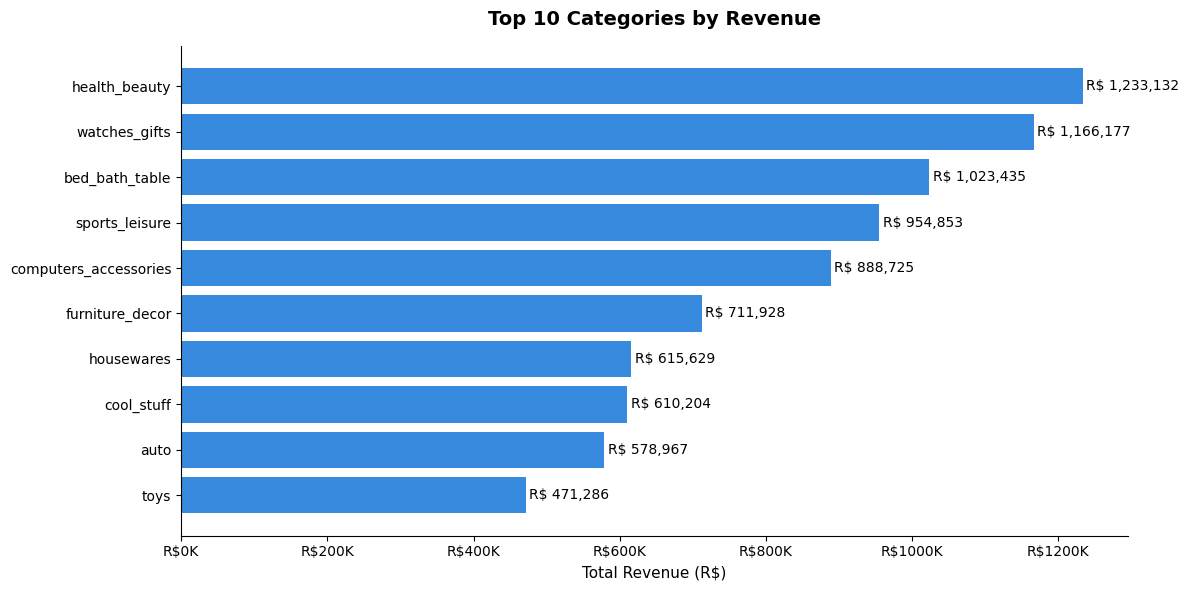

Chart saved!


In [2]:
top_categories = category.head(10).copy()

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    top_categories['product_category_name_english'],
    top_categories['total_revenue'],
    color='#378ADD'
)

# Add value labels on bars
for bar in bars:
    width = bar.get_width()
    ax.text(width + 5000, bar.get_y() + bar.get_height()/2,
            f'R$ {width:,.0f}', va='center', fontsize=10)

ax.set_xlabel('Total Revenue (R$)', fontsize=11)
ax.set_title('Top 10 Categories by Revenue', fontsize=14, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('../outputs/q1_revenue_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

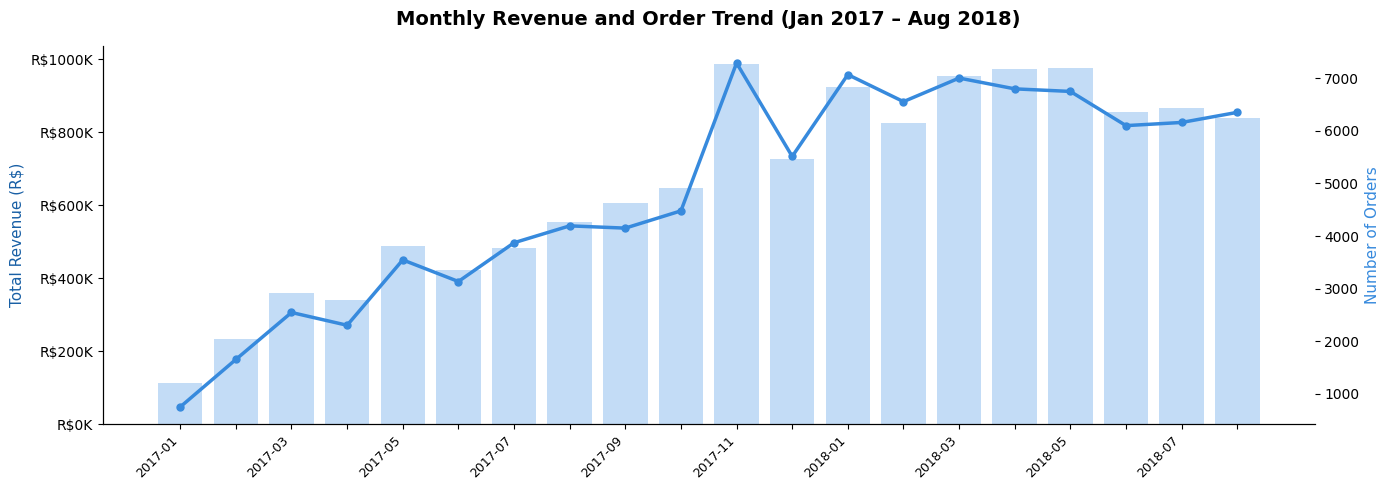

Chart saved!


In [3]:
# Remove first and last months (incomplete data)
monthly_filtered = monthly[
    (monthly['order_year_month'] >= '2017-01') &
    (monthly['order_year_month'] <= '2018-08')
].copy()

fig, ax1 = plt.subplots(figsize=(14, 5))

# Bar chart for revenue
ax1.bar(monthly_filtered['order_year_month'],
        monthly_filtered['total_revenue'],
        color='#B5D4F4', alpha=0.8, label='Revenue')
ax1.set_ylabel('Total Revenue (R$)', fontsize=11, color='#185FA5')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}K'))

# Line chart for orders on second axis
ax2 = ax1.twinx()
ax2.plot(monthly_filtered['order_year_month'],
         monthly_filtered['total_orders'],
         color='#378ADD', linewidth=2.5, marker='o', markersize=5, label='Orders')
ax2.set_ylabel('Number of Orders', fontsize=11, color='#378ADD')

# X axis labels — show every 2 months so it's readable
ticks = monthly_filtered['order_year_month'].tolist()
ax1.set_xticks(range(len(ticks)))
ax1.set_xticklabels(
    [t if i % 2 == 0 else '' for i, t in enumerate(ticks)],
    rotation=45, ha='right', fontsize=9
)

ax1.set_title('Monthly Revenue and Order Trend (Jan 2017 – Aug 2018)',
              fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../outputs/q2_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

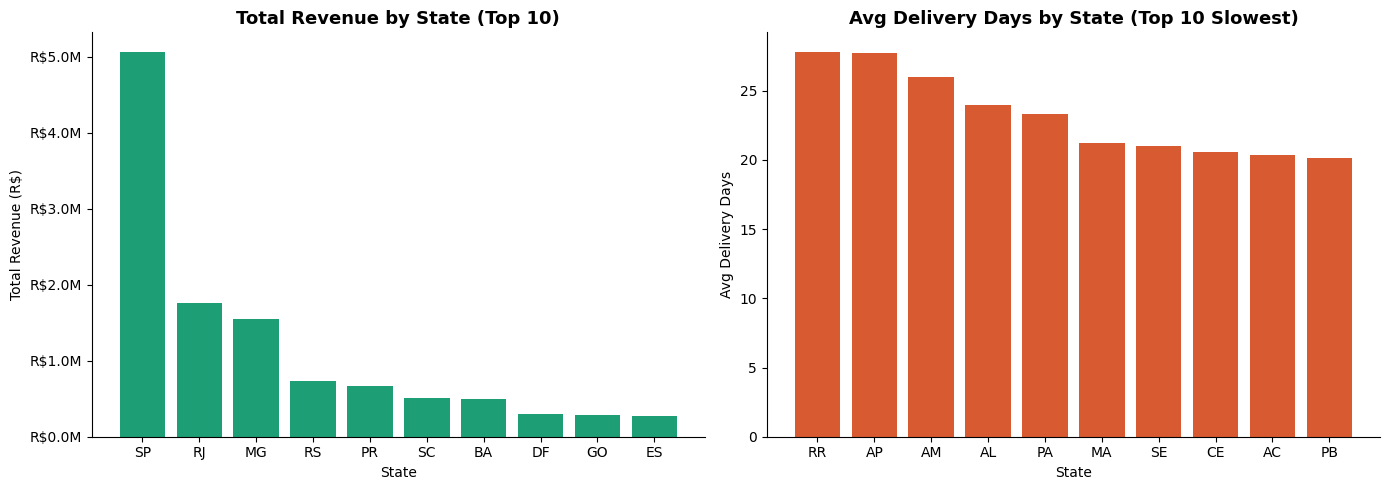

Chart saved!


In [4]:
top_states = state.head(10).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Total revenue by state
axes[0].bar(top_states['customer_state'],
            top_states['total_revenue'],
            color='#1D9E75')
axes[0].set_title('Total Revenue by State (Top 10)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('State')
axes[0].set_ylabel('Total Revenue (R$)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))

# Right: Average delivery days by state
delivery_state = master.groupby('customer_state')['delivery_days'].mean().reset_index()
delivery_state = delivery_state.sort_values('delivery_days', ascending=False).head(10)

axes[1].bar(delivery_state['customer_state'],
            delivery_state['delivery_days'],
            color='#D85A30')
axes[1].set_title('Avg Delivery Days by State (Top 10 Slowest)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('State')
axes[1].set_ylabel('Avg Delivery Days')

plt.tight_layout()
plt.savefig('../outputs/q3_state_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

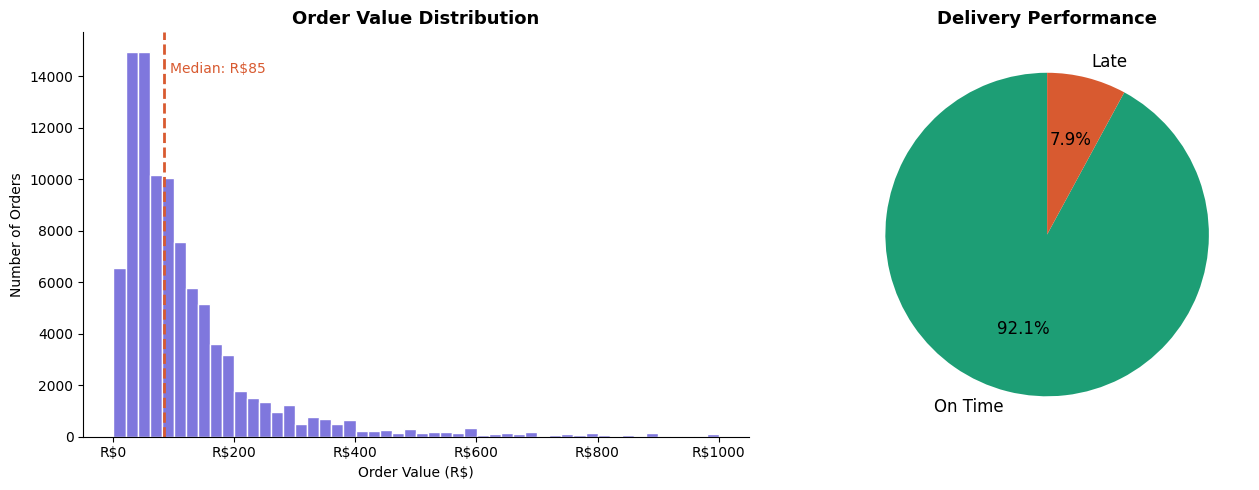

Chart saved!


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Order value distribution
order_value = master.groupby('order_id')['price'].sum().reset_index()
order_value = order_value[order_value['price'] < 1000]  # Remove extreme outliers

axes[0].hist(order_value['price'], bins=50, color='#7F77DD', edgecolor='white')
axes[0].set_title('Order Value Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Order Value (R$)')
axes[0].set_ylabel('Number of Orders')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.0f}'))

# Add median line
median_val = order_value['price'].median()
axes[0].axvline(median_val, color='#D85A30', linestyle='--', linewidth=2)
axes[0].text(median_val + 10, axes[0].get_ylim()[1] * 0.9,
             f'Median: R${median_val:.0f}', color='#D85A30', fontsize=10)

# Right: On-time delivery rate
on_time = master['delivered_on_time'].value_counts()
labels = ['On Time', 'Late']
colors = ['#1D9E75', '#D85A30']
axes[1].pie(on_time.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('Delivery Performance', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/q4_order_delivery_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [6]:
top_cat = category.iloc[0]
top_state = state.iloc[0]
best_month = monthly.loc[monthly['total_revenue'].idxmax()]
on_time_rate = master['delivered_on_time'].mean() * 100
median_order = master.groupby('order_id')['price'].sum().median()

print("=" * 50)
print("KEY BUSINESS INSIGHTS")
print("=" * 50)
print(f"1. Top revenue category : {top_cat['product_category_name_english']} (R${top_cat['total_revenue']:,.0f})")
print(f"2. Best performing state : {top_state['customer_state']} (R${top_state['total_revenue']:,.0f})")
print(f"3. Peak sales month     : {best_month['order_year_month']} ({int(best_month['total_orders'])} orders)")
print(f"4. On-time delivery rate: {on_time_rate:.1f}%")
print(f"5. Median order value   : R${median_order:.2f}")
print("=" * 50)

KEY BUSINESS INSIGHTS
1. Top revenue category : health_beauty (R$1,233,132)
2. Best performing state : SP (R$5,067,633)
3. Peak sales month     : 2017-11 (7289 orders)
4. On-time delivery rate: 92.1%
5. Median order value   : R$86.57
